In [19]:
from PyAstronomy.pyasl import foldAt
import matplotlib.pylab as plt
import numpy as np

import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve
import lightkurve as lk

1.051560878753662


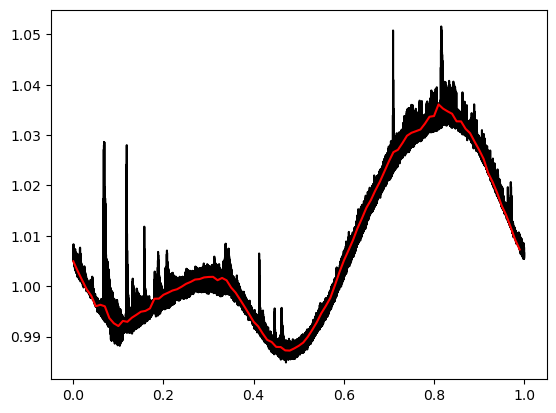

In [20]:
search_result = search_lightcurve("AU Mic")
lc2min = search_result[0].download()
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()


x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64)
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

# Generate some data ...
time = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64)
flux1 = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
t0 = 2454966.3304
t0_in_bkjd = t0 - 2454833

phases1 = foldAt(time,4.865, T0=t0_in_bkjd-0.2)

# Sort with respect to phase
# First, get the order of indices ...
sortIndi = np.argsort(phases1)
# ... and, second, rearrange the arrays.
phases1 = phases1[sortIndi]
flux1 = flux1[sortIndi]

phases_med =[]
x_med = [i/100 for i in range(100)]
for fase in x_med:
	aux = 0
	aux_2 = 0
	for i in range(len(phases1)):
		if phases1[i]>fase and phases1[i]<fase+0.01:
			aux += flux1[i]
			aux_2 += 1
	phases_med.append(aux/aux_2)

plt.plot(phases1, flux1, 'k')
plt.plot(x_med, phases_med, 'r-', label = 'median value')
print(np.max(flux1))

In [21]:
#dados parâmetros###
dados_1=np.loadtxt('temp_ener_s1.txt')

temp_med = dados_1[:,0]
ener_setor1 = dados_1[:,1]
enerlog10 = np.log10(ener_setor1)
print(enerlog10)

[33.77838281 32.62380215 33.14652182 32.37795248 33.65943793 32.88899282
 32.18087964 32.83423054 32.65797703 32.12745469 33.71343762 32.98267232
 34.10444955 33.51042972 32.87115069 32.98544713 33.30100177 33.11125243
 32.17669595 32.57904238 32.49435917 32.51497785 32.70172596 32.83588453
 33.51626691 32.50927916 33.15294235 31.95701362 33.05351636 32.80439434
 33.96701601 33.47928155 32.37902617]


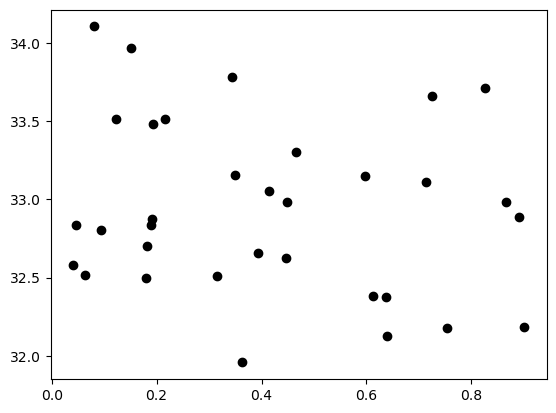

In [22]:
t0 = 2454966.3304
t0_in_bkjd = t0 - 2454833

fase1 = foldAt(temp_med,4.865, T0=t0_in_bkjd-0.2)
plt.plot(fase1, enerlog10, 'ko')


[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
[2, 3, 1, 6, 1, 0, 3, 2, 3, 1, 0, 1, 3, 0, 2, 1, 1, 2, 1, 0]


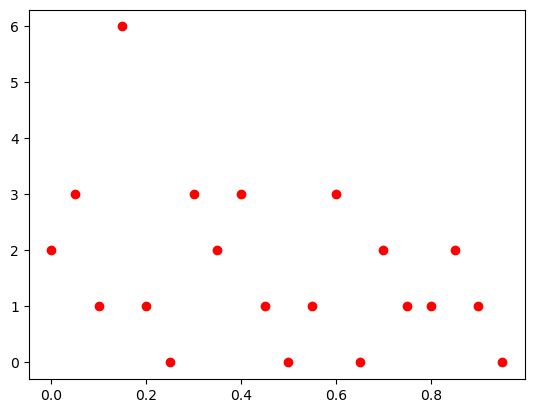

In [52]:
phases = foldAt(temp_med,4.865, T0=t0_in_bkjd-0.2)
# Sort with respect to phase
# First, get the order of indices ...
sortIndi = np.argsort(phases)
# ... and, second, rearrange the arrays.
flux = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)

phases = phases[sortIndi]
flux = flux[sortIndi]


phases_med0 =[]
x_med0 = [i/20 for i in range(20)]
for fase in x_med0:
	aux = 0
	aux_2 = 0
	for i in range(len(phases)):
		if phases[i]>fase and phases[i]<fase+0.05:
			aux += flux[i]
			aux_2 += 1
	phases_med0.append(aux_2)

plt.plot(x_med0, phases_med0, 'ro')
print(x_med0)
print(phases_med0)


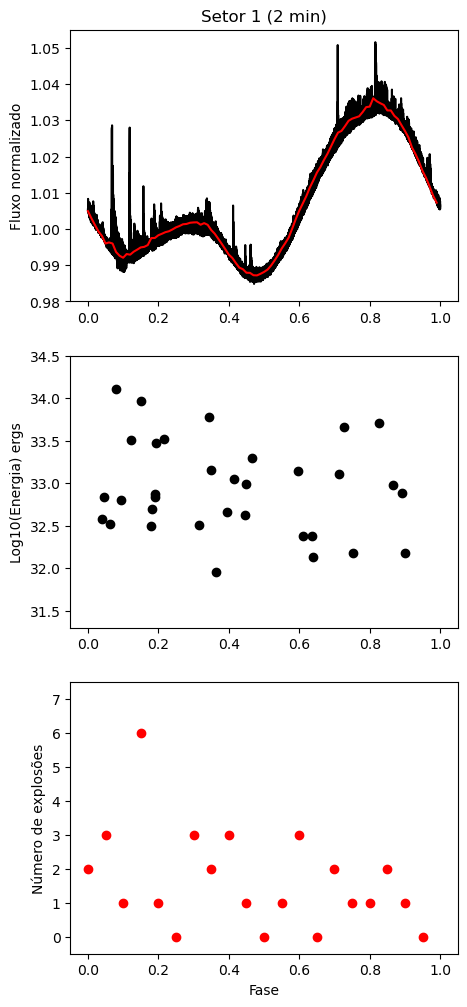

In [39]:
fig,(ax1,ax2,ax3) = plt.subplots(3,1,figsize=(5,12))

ax1.set_title('Setor 1 (2 min)')
ax1.plot(phases1, flux1, 'k',x_med, phases_med, 'r-', label = 'median value')
ax1.set_ylabel('Fluxo normalizado')
ax2.plot(fase1, enerlog10, 'ko')
ax2.set_ylabel('Log10(Energia) ergs')
ax3.plot(x_med0, phases_med0, 'ro')
#ax3.set_ylabel('Relative flux [ppt]')
ax1.set_xlim(-0.050,1.050)
ax2.set_xlim(-0.050,1.050)
ax3.set_xlim(-0.050,1.050)

ax1.set_ylim(0.98,1.055)
ax2.set_ylim(31.3,34.5)
ax3.set_ylim(-0.5,7.5)



ax3.set_xlabel('Fase')
ax3.set_ylabel('Número de explosões')
plt.show()